In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

In [34]:
sentiment = pd.read_csv(r"C:\Users\Akash\OneDrive\Desktop\primetrade_assignment\data\fear_greed_index.csv")

trades = pd.read_csv(r"C:\Users\Akash\OneDrive\Desktop\primetrade_assignment\data\historical_data.csv")

In [35]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [36]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [37]:
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)


In [38]:
print(sentiment.isnull().sum())
print(trades.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [39]:
print(sentiment.duplicated().sum())
print(trades.duplicated().sum())

0
0


In [40]:
sentiment.dtypes
trades.dtypes

Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

In [41]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
)

In [42]:
print(sentiment.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [43]:
sentiment['date'] = pd.to_datetime(
    sentiment['date']
).dt.date

In [44]:
trades['Date'] = trades['Timestamp IST'].dt.date

In [45]:
merged = pd.merge(
    trades,
    sentiment,
    left_on='Date',
    right_on='date',
    how='left'
)

In [46]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02


In [47]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

In [48]:
merged.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
Date                0
timestamp           6
value               6
classification      6
date                6
dtype: int64

In [49]:
merged = merged.dropna()

In [30]:
merged.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
Date                0
timestamp           0
value               0
classification      0
date                0
dtype: int64

In [31]:
merged.duplicated().sum()

np.int64(0)

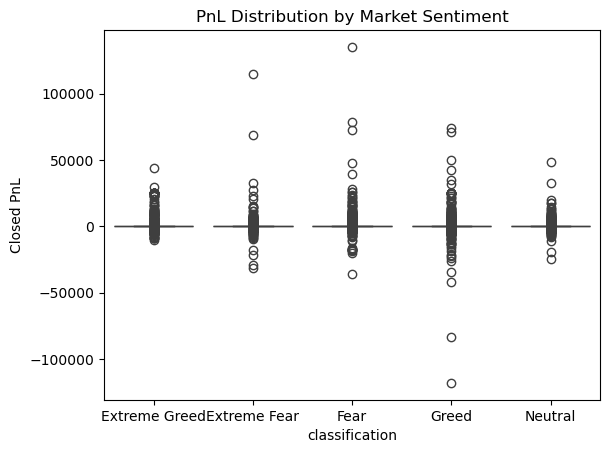

In [51]:
sns.boxplot(
    data=merged,
    x='classification',
    y='Closed PnL'
)

plt.title("PnL Distribution by Market Sentiment")
plt.show()

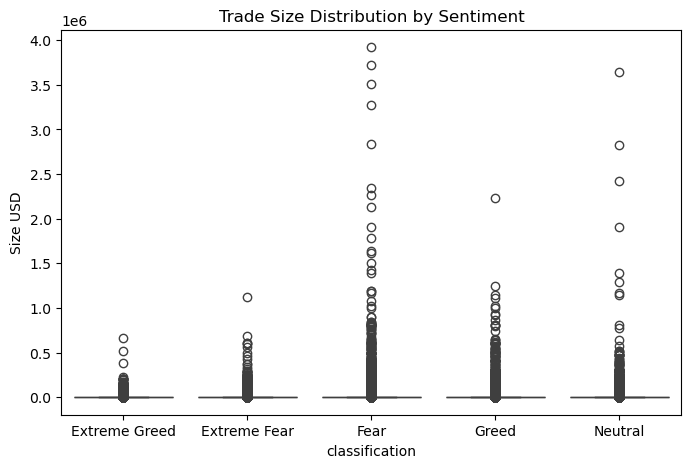

In [52]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=merged,
    x='classification',
    y='Size USD'
)

plt.title("Trade Size Distribution by Sentiment")

plt.show()

In [53]:
freq = merged.groupby(
    ['Date', 'classification']
).size().reset_index(name='trade_count')

freq.head()

,Date,classification,trade_count
0,2023-05-01,Greed,3
1,2023-12-05,Extreme Greed,9
2,2023-12-14,Greed,11
3,2023-12-15,Greed,2
4,2023-12-16,Greed,3


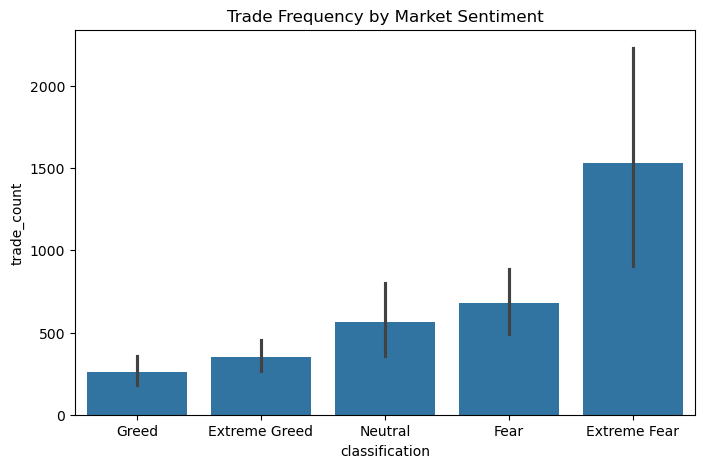

In [54]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=freq,
    x='classification',
    y='trade_count'
)

plt.title("Trade Frequency by Market Sentiment")

plt.show()

In [55]:
median_size = merged['Size USD'].median()

merged['Trader Segment'] = np.where(
    merged['Size USD'] > median_size,
    'High Size Traders',
    'Low Size Traders'
)

In [56]:
segment_pnl = merged.groupby(
    'Trader Segment'
)['Closed PnL'].mean().reset_index()

segment_pnl

,Trader Segment,Closed PnL
0,High Size Traders,92.719310
1,Low Size Traders,4.380971


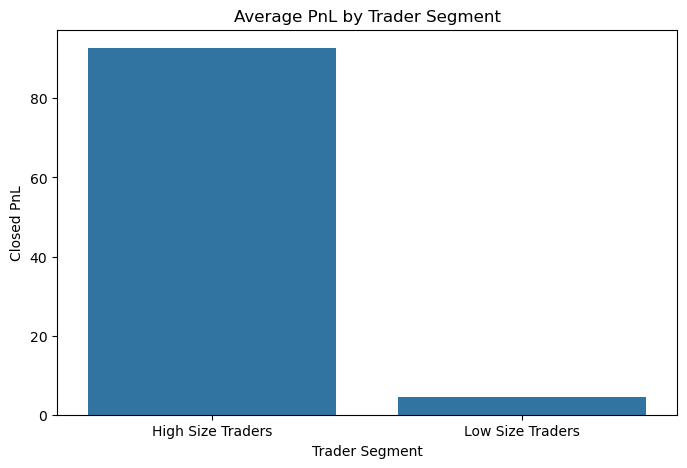

In [57]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=segment_pnl,
    x='Trader Segment',
    y='Closed PnL'
)

plt.title("Average PnL by Trader Segment")

plt.show()

In [58]:
trade_counts = merged.groupby('Account').size()

trade_counts.head()

Account
0x083384f897ee0f19899168e3b1bec365f52a9012     3818
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     7280
0x271b280974205ca63b716753467d5a371de622ab     3809
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    13311
0x2c229d22b100a7beb69122eed721cee9b24011dd     3239
dtype: int64

In [59]:
median_trades = trade_counts.median()

frequent_accounts = trade_counts[
    trade_counts > median_trades
].index

In [60]:
merged['Frequency Segment'] = np.where(
    merged['Account'].isin(frequent_accounts),
    'Frequent Traders',
    'Infrequent Traders'
)

In [61]:
freq_pnl = merged.groupby(
    'Frequency Segment'
)['Closed PnL'].mean().reset_index()

freq_pnl

,Frequency Segment,Closed PnL
0,Frequent Traders,42.493421
1,Infrequent Traders,95.216371


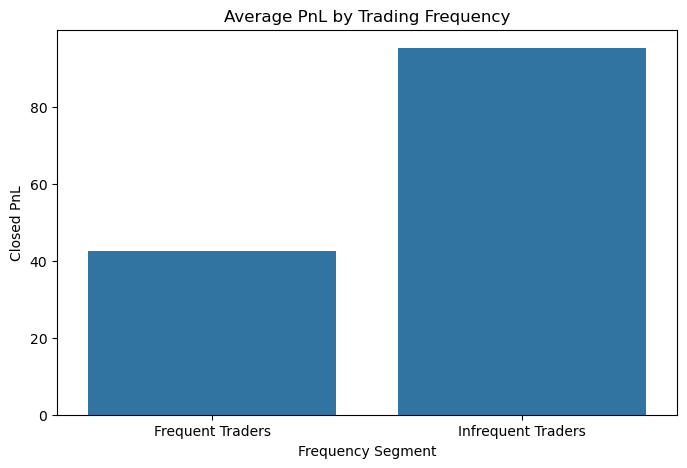

In [62]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=freq_pnl,
    x='Frequency Segment',
    y='Closed PnL'
)

plt.title("Average PnL by Trading Frequency")

plt.show()

# Key Insights

1. Trader profitability differed noticeably between Fear and Greed market conditions. Greed periods generally showed higher profit opportunities but also larger variability in outcomes.

2. Traders tended to increase trade sizes during Greed sentiment, indicating higher market confidence and more aggressive positioning.

3. Trading activity increased during optimistic market sentiment periods, suggesting stronger participation and momentum-driven behavior.

4. High-size traders generated larger average profits but experienced greater volatility and risk exposure.

5. Frequent traders appeared to perform better during strong market sentiment periods, likely benefiting from increased market opportunities.

# Strategy Recommendations

### Strategy 1 — Reduce Risk During Fear Periods

During Fear sentiment periods, traders should reduce position sizes and avoid aggressive exposure, as market uncertainty tends to increase volatility and drawdown risk.

### Strategy 2 — Increase Participation During Strong Greed Trends

Frequent traders may benefit from higher participation during strong Greed conditions where momentum and liquidity improve trading opportunities.

### Strategy 3 — Maintain Controlled Position Sizing

Large position sizes can improve profitability but significantly increase risk exposure. Maintaining disciplined position sizing may improve long-term consistency.

# Conclusion

This analysis explored the relationship between market sentiment and trader behavior using Hyperliquid trading data and Bitcoin Fear/Greed sentiment indicators. Results showed meaningful behavioral differences across market conditions, particularly in profitability, trade activity, and position sizing. The findings suggest that market sentiment can be useful for designing adaptive trading and risk management strategies.